/Users/rbrady0110/micromamba/envs/doubles/lib/python3.13/site-packages/lenstronomy/Data/psf.py:95: UserWarning: Input PSF model has at least one negative element, which is unphysical except for a PSF of an interferometric array.
  warnings.warn(
/var/folders/74/9yc0dt9d53z15d2qpmgpxv4h0000gn/T/ipykernel_24824/4055506977.py:72: RuntimeWarning: invalid value encountered in log10
  sci_plot = ax[plot_idx].imshow(np.log10(kernel_psf_class), cmap='viridis', origin='lower')


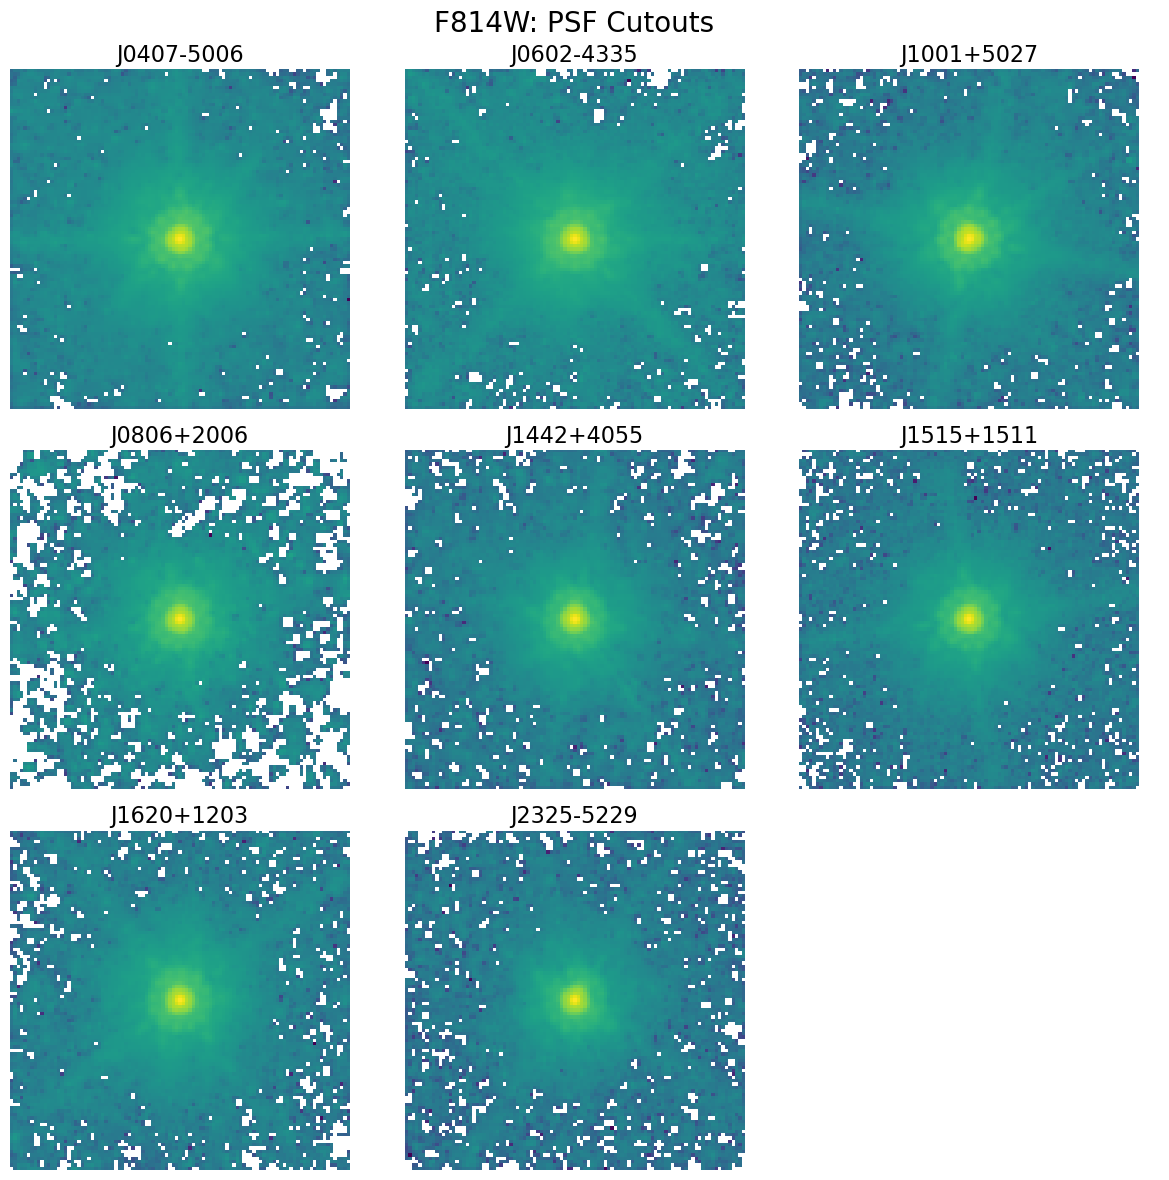

In [1]:
# plot the individual PSF's in a filter

import os
import matplotlib.pyplot as plt
import numpy as np
import astropy.io.fits as pyfits
from lenstronomy.Data.psf import PSF
from lenstronomy.Util import kernel_util

# quasar dictionary with filters
F814W = {
    'J0407-5006': ['F814W'],
    'J0602-4335': ['F814W'],
    'J1001+5027': ['F814W'],
    'J0806+2006': ['F814W'],
    'J1442+4055': ['F814W'],
    'J1515+1511': ['F814W'],
    'J1620+1203': ['F814W'],
    'J2325-5229': ['F814W'],
}

F475X = {
    'J0407-5006': ['F475X'],
    'J0602-4335': ['F475X'],
    'J0806+2006': ['F475X'],
    'J1001+5027': ['F475X'],
    'J1442+4055': ['F475X'],
    'J1515+1511': ['F475X'],
    'J1620+1203': ['F475X'],
    'J2325-5229': ['F475X'],
}

F160W = {
    'J0407-5006': ['F160W'],
    'J0602-4335': ['F160W'],
    'J0806+2006': ['F160W'],
    'J1001+5027': ['F160W'],
    'J1442+4055': ['F160W'],
    'J1515+1511': ['F160W'],
    'J1620+1203': ['F160W'],
    'J2325-5229': ['F160W'],
}

filt = F814W

ncols = 3
num_quasars = sum(len(bands) for bands in filt.values()) 
nrows = (num_quasars + ncols - 1) // ncols 

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12,12))
ax = ax.flatten()  

plot_idx = 0  

for quasar_name, bands in filt.items():
    for band in bands:

        PSF_retrieved = f'../../cutout_data/{quasar_name}/{band}/outputs/full_PSF.fits'
        kernel = pyfits.getdata(PSF_retrieved)
        psf_type = 'PIXEL'  # 'gaussian', 'pixel', 'NONE'
        kernel_size = 301

        kernel_cut = kernel_util.cut_psf(kernel, kernel_size)
        kwargs_psf3 = {'psf_type': psf_type, 'kernel_point_source': kernel_cut, 
                      'point_source_supersampling_factor': 3, 
                      }

        psf_class = PSF(**kwargs_psf3)
        kernel_psf_class = psf_class.kernel_point_source

        # plot the PSF image
        sci_plot = ax[plot_idx].imshow(np.log10(kernel_psf_class), cmap='viridis', origin='lower')
        ax[plot_idx].set_title(f'{quasar_name}', fontsize = 16)

        ax[plot_idx].axis('off')  # turn off axis
        plot_idx += 1  

# hide any unused subplots
for j in range(plot_idx, nrows * ncols):
    ax[j].axis('off')

if filt == F814W:
    title = 'F814W'
elif filt == F475X:
    title = 'F475X'
else:
    title = 'F160W'

fig.suptitle(f'{title}: PSF Cutouts', fontsize = 20)
plt.tight_layout()
plt.show()
